### Applying Isolation Forest algorithm to flag unstable satellites
- We will now train Isolation forest on each satellite cluster 

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest


In [82]:
# 1. Read the unscaled clustered dataset
unscaled_df = pd.read_csv('../data/05_labeled/satellites_unscaled_labeled.csv')
# 2. Read the scaled clustered dataset
scaled_df = pd.read_csv('../data/05_labeled/satellites_scaled_labeled.csv')

In [83]:
unscaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,4466,0.001228,1.211000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,82995,0.000097,7.400000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,93412,0.000160,8.900000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,93673,0.000319,1.750000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,3753,0.003397,2.236400e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


In [84]:
scaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,-2.028257,0.712370,1.364445,-0.995301,-0.036004,1.179214,-0.671252,0.157480,-0.029430,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,-2.408049,0.491618,1.365160,-0.958414,-0.932404,1.642944,5.245827,-0.035489,-0.033018,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,-2.720370,2.156456,1.353187,0.367233,-0.923497,1.495113,6.030737,-0.024856,-0.032971,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,-2.677392,2.053050,1.349347,-0.460794,1.381571,-1.088367,6.050403,0.002381,-0.032700,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,-0.448113,-0.009803,0.382534,-0.184836,1.362099,-1.349797,-0.724976,0.527563,0.037320,-0.013178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


### Feature selection for Isolation Forest
- It is not a good idea to use all the features for traning the model.
- Some features are redundant and some are not contributing to the model.
- Redundant features often have high correlation with each other (correlation > 0.9).


Steps : 

1. Remove redundant features using correlation (r>0.9)
.  


#### Some features to never use in isolation forest : 
1. **One hot encoded features** : These are not contributing to the anomaly model, because they are not scale invariant.
2. **Revolution at epoch**: It's more of a metadata field than a physical orbital parameter


In [85]:
# Step 1 : Remove redundant/ unwanted columns
scaled_df = scaled_df.drop(columns = [col for col in scaled_df.columns if col.startswith('SAT_TYPE_')] + ['REV_AT_EPOCH'])

corr = scaled_df.corr(numeric_only=True).abs()

# keep only the upper triangle
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find the features having corr > 0.9
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

to_drop

['MEAN_ANOMALY',
 'ORBIT_PERIOD_SEC',
 'SEMI_MAJOR_AXIS',
 'ORBIT_HEIGHT',
 'PERIGEE',
 'APOGEE',
 'ORBITAL_SPEED']

In [86]:
scaled_df = scaled_df.drop(columns = to_drop)

In [87]:
scaled_df.head(2)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,AGE_SINCE_LAUNCH,CLUSTER
0,-2.028257,0.712370,1.364445,-0.995301,-0.036004,0.157480,-0.029430,-0.013178,16.750407,2
1,-2.408049,0.491618,1.365160,-0.958414,-0.932404,-0.035489,-0.033018,-0.013178,16.750407,2


In [88]:
# Select the same features in the unscaled dataset for actual model training
unscaled_df = unscaled_df[scaled_df.columns]
unscaled_df.head(2)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,AGE_SINCE_LAUNCH,CLUSTER
0,13.763517,0.002716,90.2215,67.2697,159.0699,0.001228,1.211000e-05,0.0,61.925,2
1,13.528817,0.002040,90.2363,71.2062,74.4339,0.000097,7.400000e-07,0.0,61.925,2


---
## 🛰️ Cluster-Wise Isolation Forest: Abstract Workflow

Below is a high-level, implementation-agnostic explanation of how to run
**Isolation Forest separately on each cluster**, with parameters that adapt
to each  size and spread.

---

### 1. **Prepare Cluster Subsets**
After clustering (e.g., via K-Means), split the dataset into groups:

- Each group represents one cluster.
- Each cluster is treated as its own “local data pocket.”
- Compute basic stats per cluster:
  - `nᵢ` → number of points  
  - `σᵢ` → average standard deviation (or IQR) -> take average sd of every feature

These two values guide all later parameter choices.

---

### 2. **Set Cluster-Specific Parameters**
For every cluster **Cᵢ**:

**a. n_estimators (tree count)**  
Adjust based on cluster size:
- Small clusters → fewer trees  
- Medium → moderate  
- Large → slightly more

**b. max_samples**  
Use the smaller of:
- the cluster size,  
- a fixed cap (traditional ≈ 256)

This keeps trees consistent but efficient.

**c. contamination**  
Link sensitivity to cluster spread:
- Tight/compact clusters → very low contamination  
- Medium spread → moderate  
- High-spread/noisy clusters → slightly higher

This makes each model respect its own local variance.

**d. max_features**  
Use all features inside each cluster.  
Local models benefit from full context.

**e. bootstrap**  
Only enable if the cluster is very large.

---

### 3. **Train a Local Isolation Forest Inside Each Cluster**
- Fit the detector using that cluster’s own data only.
- The model isolates anomalies relative to the internal geometry of the cluster.
- No global interference from other clusters.

This produces cluster-wise anomaly scores.

---

### 4. **Normalize Scores Inside Each Cluster**
Each cluster’s score distribution is different.

Normalize scores cluster-wise, for example:
- min–max scaling  
- or z-score

This ensures that anomaly scores across clusters become comparable.

---

### 5. **Merge All Results**
Bring everything back together:

- Reattach the cluster label  
- Append the normalized anomaly score  
- Combine all cluster outputs into one final dataframe

The final result gives:
- local anomaly detection quality  
- global comparability  
- very stable and interpretable behavior

---

### 🧭 Outcome
You get a lightweight, cluster-sensible anomaly system where:
- each cluster has a detector tuned to its density and size  
- anomaly detection is cleaner and more precise  
- merged scores reflect global anomaly significance without distortion

This structure is simple, scalable, and strong for datasets with natural subgroups
(e.g., orbital shells, behavioral clusters, sensor regimes, etc.).


---


- Check the raw size of the clusters

In [89]:
scaled_df['CLUSTER'].value_counts()

CLUSTER
1    4610
0    4389
4    2106
2    1458
3     184
Name: count, dtype: int64

---
### 1. Basic stats for each cluster -> Use scaled dataset for unbiased Standard Deviation
1. Satellite count
2. Average standard deviation across numerical features

In [90]:
# Find number of samples and mean SD 
def compute_base_stats(scaled_df):

    cluster_size_list = []
    sd_list = []
    value_counts = scaled_df['CLUSTER'].value_counts()
    
    # For each cluster: compute clust size and average SD
    for clust_id in sorted(value_counts.index):
        # --- clust size ---
        cluster_size_list.append(value_counts.loc[clust_id]) 
        
        # --- Average SD ---
        clust_rows = scaled_df[scaled_df['CLUSTER'] == clust_id] # filter out only this cluster satellites

        numeric_cols = clust_rows.select_dtypes(include = np.number).drop(columns=['CLUSTER']) # get numeric column names
        encoded_cols = [col for col in numeric_cols.columns if col.startswith('SAT_TYPE_')] # Filter out encoded features, as we dont need them for SD
        numeric_cols = numeric_cols.drop(columns = encoded_cols).columns
        
        total_sd = 0 # Find the SD for each feature, then add the SD for the current cluster's all features
        for feature in numeric_cols:
            sd = clust_rows[feature].std()
            total_sd += sd

        avg_sd = total_sd / len(numeric_cols) 
        sd_list.append(avg_sd)
        
    return cluster_size_list, sd_list
        

In [91]:
# Call the function
cluster_size, avg_sd = compute_base_stats(scaled_df)

In [92]:
cluster_size

[np.int64(4389), np.int64(4610), np.int64(1458), np.int64(184), np.int64(2106)]

In [93]:
avg_sd

[0.4038620105667234,
 0.6531402645433864,
 1.0680126139419386,
 1.0058303907617387,
 0.4825540329256075]

----
### 2. Setting cluster specific parameters for Isolation Forest models
- For each cluster based on the size and Average SD, find:
1. **n_estimators**: Tree count
2. **max_samples**:  Num of samples to use in each isolation tree
3. **contamination**: Threshold by which anomaly will be selected
4. **max_features**: Use all features in every tree

---
## Mapping Cluster Stats → Isolation Forest Parameters (Intuition + Value Ranges)

### Inputs:
- **cluster_size** → number of satellites in this cluster  
- **cluster_sd** → how spread-out the cluster is (average SD of continuous features)

These two fully define how the Isolation Forest should be shaped.

---

## 1. contamination (comes from cluster_sd)

### Intuition:
“Tight cluster → fewer anomalies. Loose cluster → more anomalies.”

### Suggested values:
- **Low SD** (very tight) → `0.01` to `0.02`  
- **Medium SD** → `0.03` to `0.06`  
- **High SD** (very loose) → `0.08` to `0.12`  

---

## 2. n_estimators (comes from cluster_size)

### Intuition:
“Bigger clusters have more structure → need more trees.”

### Suggested values:
- **cluster_size < 100** → `50–100` trees  
- **100 ≤ size ≤ 1000** → `150–200` trees  
- **size > 3000** → `250–350` trees  

---

## 3. max_samples (also from cluster_size)

### Intuition:
“Small cluster → smaller subsamples. Big cluster → bigger subsamples.”

### Suggested values:
- **cluster_size < 100** → `40–80%` of the cluster  
- **100 ≤ size ≤ 1000** → `60–90%` of the cluster  
- **size > 3000** → fixed cap like `512` or `1024` samples  

---

## Summary Mapping
- **cluster_sd → contamination**  
- **cluster_size → n_estimators**  
- **cluster_size → max_samples**  

These three settings adjust the Isolation Forest to each cluster’s personality.


----
### Final value tables
#### 1. Contamination rule: 



Contamination is chosen by first selecting a system-wide range:
- Tight system  →  0.005 to 0.03  
- Normal system →  0.01  to 0.08  
- Loose system  →  0.02  to 0.12  

The chosen range is stretched across k positions (k = number of clusters) to form a smooth scale of contamination values from minimum to maximum.  
Cluster SD ordering determines each cluster’s position on this scale: tighter SD maps to lower contamination, looser SD maps to higher contamination, and identical SD values map to the same position.


---

#### 2. n_estimators rule: 
| Cluster Size Range | Meaning      | Recommended n_estimators |
| ------------------ | ------------ | ------------------------ |
| **< 100**          | Very Small   | **50–80**                |
| **100–1000**       | Small–Medium | **150–200**              |
| **1000–3000**      | Medium–Large | **200–250**              |
| **> 3000**         | Very Large   | **250–350**              |


---

#### 3. max_samples rule:
| Cluster Size Range | Meaning      | Recommended max_samples                      |
| ------------------ | ------------ | -------------------------------------------- |
| **< 100**          | Very Small   | **40–80%** of cluster size                   |
| **100–1000**       | Small–Medium | **60–90%** of cluster size                   |
| **1000–3000**      | Medium–Large | **approx 90–95%** of cluster size            |
| **> 3000**         | Very Large   | **Fixed cap: 512–1024** (regardless of size) |



In [94]:
def find_model_parameter(clust_sd, cluster_size):

    contamination_list, n_estimator_list, max_sample_list = [None]*len(clust_sd), [None]*len(clust_sd), [None]*len(clust_sd)

    # 1. Contamination (based on cluster SD)

    # Step 1: Compute SD spread
    spread = max(clust_sd) - min(clust_sd)
    
    # Step 2: Choose min/max contamination based on spread
    if spread <= 0.2:
        min_cont, max_cont = 0.005, 0.03
    elif spread <= 0.6:
        min_cont, max_cont = 0.01, 0.08
    else:
        min_cont, max_cont = 0.02, 0.12
    
    # Step 3: Generate contamination values (dynamic for any k)
    selected_sd_range = np.linspace(min_cont, max_cont, len(clust_sd))
    
    # Step 4: Group clusters by SD (equal SD → equal contamination)
    unique_sds = sorted(set(clust_sd))
    sd_to_rank = {sd: i for i, sd in enumerate(unique_sds)}
    
    # Step 5: Assign contamination using grouped ranks
    for i in range(len(clust_sd)):
        rank = sd_to_rank[clust_sd[i]] # which rank does the cluster with This SD has
        contamination_list[i] = selected_sd_range[rank]

    # ----------------------------------------------------------
    
    # 2. n_estimators &  max_samples (based on cluster size)

    for i in range(len(cluster_size)):
        if cluster_size[i] < 100: # Small sized cluster
            n_estimator_list[i] = 70
            max_sample_list[i] = int(cluster_size[i] * 0.5)
            
        elif cluster_size[i] <1000: # small to medium sized cluster
            n_estimator_list[i] = 150
            max_sample_list[i] = int(cluster_size[i] * 0.7)

        elif cluster_size[i] <3000: #  medium to large sized cluster
            n_estimator_list[i] = 200
            max_sample_list[i] = int(cluster_size[i] * 0.9)
            
        else:                     # Large sized cluster
            n_estimator_list[i] = 350
            max_sample_list[i] = 1000
     # ----------------------------------------------------------

    return contamination_list, n_estimator_list, max_sample_list
    
        

In [95]:
contamination_list, n_estimator_list, max_sample_list = find_model_parameter(avg_sd, cluster_size)

In [96]:
print(f"{'Cluster ID':<12} | {'Contamination':<15} | {'n_estimators':<12} | {'max_samples':<12}")
print("-" * 65)

for i in range(len(cluster_size)):
    print(f"{str(i):<12} | {contamination_list[i]:<15} | {n_estimator_list[i]:<12} | {max_sample_list[i]:<12}")


Cluster ID   | Contamination   | n_estimators | max_samples 
-----------------------------------------------------------------
0            | 0.02            | 350          | 1000        
1            | 0.06999999999999999 | 350          | 1000        
2            | 0.12            | 200          | 1312        
3            | 0.095           | 150          | 128         
4            | 0.045           | 200          | 1895        


In [97]:
cluster_size

[np.int64(4389), np.int64(4610), np.int64(1458), np.int64(184), np.int64(2106)]

---

### Training Isolation Forest on each cluster

In [98]:
unscaled_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,AGE_SINCE_LAUNCH,CLUSTER
0,13.763517,0.002716,90.2215,67.2697,159.0699,0.001228,1.211000e-05,0.0,61.925,2
1,13.528817,0.002040,90.2363,71.2062,74.4339,0.000097,7.400000e-07,0.0,61.925,2
2,13.335813,0.007139,89.9887,212.6762,75.2749,0.000160,8.900000e-07,0.0,60.925,2
3,13.362372,0.006822,89.9093,124.3111,292.9140,0.000319,1.750000e-06,0.0,60.925,2
4,14.739996,0.000504,69.9162,153.7607,291.0755,0.003397,2.236400e-04,0.0,58.925,2


In [99]:
# Function to train model
def train_iso_model(df, contamination, n_estimator, max_sample):

    iso_forest_models = {} # Store cluster ID: related iso model
    
    for cluster_id in sorted(list(set(df['CLUSTER']))):
        # Extract rows for this cluster ID
        cluster_rows = df[df['CLUSTER'] == cluster_id]

        iso_model = IsolationForest(n_estimators=n_estimator[cluster_id], 
                                   max_samples=max_sample[cluster_id],
                                   contamination=contamination[cluster_id],
                                   max_features=1.0, # Consider all features in a tree
                                   random_state=101)
        # Train the model
        iso_model.fit(cluster_rows.drop(columns=['CLUSTER']))
        iso_forest_models[cluster_id] = iso_model # Save the model to the dictionary

        print(f'Isolation forest trained for cluster {cluster_id}')

    return iso_forest_models

In [100]:
# Call the function to train (on unscaled dataset -> Isolation forest does not need scaling)
iso_forest_models = train_iso_model(unscaled_df, contamination_list, n_estimator_list, max_sample_list)

Isolation forest trained for cluster 0
Isolation forest trained for cluster 1
Isolation forest trained for cluster 2
Isolation forest trained for cluster 3
Isolation forest trained for cluster 4


In [101]:
iso_forest_models

{0: IsolationForest(contamination=np.float64(0.02), max_samples=1000,
                 n_estimators=350, random_state=101),
 1: IsolationForest(contamination=np.float64(0.06999999999999999), max_samples=1000,
                 n_estimators=350, random_state=101),
 2: IsolationForest(contamination=np.float64(0.12), max_samples=1312,
                 n_estimators=200, random_state=101),
 3: IsolationForest(contamination=np.float64(0.095), max_samples=128,
                 n_estimators=150, random_state=101),
 4: IsolationForest(contamination=np.float64(0.045), max_samples=1895,
                 n_estimators=200, random_state=101)}

In [102]:
# function to extract the anomaly information
def get_anomaly(iso_forest_models, df):

    # Prepare the anomaly realted features
    df['ANOMALY_LABEL'] = 0
    df['ANOMALY_SCORE'] = 0.0
    
    for cluster_id, model in iso_forest_models.items():
        # Select all rows belonging to this cluster
        mask = df['CLUSTER'] == cluster_id

        # Extract necessary features (features + rows belonging to the cluster)
        features = df.loc[mask].drop(columns=['CLUSTER', 'ANOMALY_LABEL', 'ANOMALY_SCORE'])

        # Predict using model trained on exact features
        labels = model.predict(features) 
        score = model.decision_function(features)

        # Store the results back to unscaled DF
        df.loc[mask, 'ANOMALY_LABEL'] = labels
        df.loc[mask, 'ANOMALY_SCORE'] = score

        print(f'Isolation forest predicted for cluster {cluster_id}')

    return df

In [103]:
anomaly_df = get_anomaly(iso_forest_models, unscaled_df)

Isolation forest predicted for cluster 0
Isolation forest predicted for cluster 1
Isolation forest predicted for cluster 2
Isolation forest predicted for cluster 3
Isolation forest predicted for cluster 4


In [104]:
anomaly_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,AGE_SINCE_LAUNCH,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,13.763517,0.002716,90.2215,67.2697,159.0699,0.001228,1.211000e-05,0.0,61.925,2,-1,-0.114399
1,13.528817,0.002040,90.2363,71.2062,74.4339,0.000097,7.400000e-07,0.0,61.925,2,-1,-0.077496
2,13.335813,0.007139,89.9887,212.6762,75.2749,0.000160,8.900000e-07,0.0,60.925,2,-1,-0.098555
3,13.362372,0.006822,89.9093,124.3111,292.9140,0.000319,1.750000e-06,0.0,60.925,2,-1,-0.112472
4,14.739996,0.000504,69.9162,153.7607,291.0755,0.003397,2.236400e-04,0.0,58.925,2,-1,-0.170740


In [105]:
anomaly_df['ANOMALY_LABEL'].value_counts()

ANOMALY_LABEL
 1    12048
-1      699
Name: count, dtype: int64

----


### Making a Streamlit ready dataset combining the result of clustering and anomaly detection, also useful for forecasting / risk analysis

In [106]:
# Read the orignal dataset to get the missing columns
original_df = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

streamlit_ready_df = original_df.join(anomaly_df[['CLUSTER', 'ANOMALY_LABEL', 'ANOMALY_SCORE']])
    

In [107]:
streamlit_ready_df.head()

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,CALSPHERE 1,2025-12-04 15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,900,4466,...,7354.923145,983.923145,956.945702,996.900587,7.361725,61.925,C,2,-1,-0.114399
1,CALSPHERE 2,2025-12-04 14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,902,82995,...,7439.741868,1068.741868,1046.564050,1076.919685,7.319640,61.925,E,2,-1,-0.077496
2,TEMPSAT 1,2025-12-04 15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,1512,93412,...,7511.351540,1140.351540,1079.728002,1186.975079,7.284665,60.925,E,2,-1,-0.098555
3,CALSPHERE 4A,2025-12-04 16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,1520,93673,...,7501.395143,1130.395143,1072.218375,1174.571911,7.289498,60.925,H,2,-1,-0.112472
4,OPS 5712 (P/L 160),2025-12-04 16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,2826,3753,...,7026.399599,655.399599,644.855483,651.943715,7.531860,58.925,A,2,-1,-0.170740


#### Save the dataset

In [108]:
streamlit_ready_df.to_csv('../data/06_streamlit_ready/anomaly_clustered.csv', index=False)

In [109]:
# Validate the dataset row order
same = (original_df['OBJECT_NAME'].values == streamlit_ready_df['OBJECT_NAME'].values)

print("Rows matching:", same.sum(), "/", len(same))
print("All same?", same.all())

Rows matching: 12747 / 12747
All same? True


### Interpreting the results

#### 1. Sort satellites in that cluster by anomaly severity

In [110]:
def anomaly_severity(cluster_id, df):
    # Get anomalies from this cluster id sorted by anomaly score
    cluster_df = df[df['CLUSTER']==cluster_id].sort_values(by='ANOMALY_SCORE')

    # Get top 10 risky satellites
    top_10 = cluster_df.head(10)
    return top_10, cluster_df
    

In [111]:
print('top 10 anomalous satellites within each cluster')
for i in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the functon
    top_10, cluster_df = anomaly_severity(i, anomaly_df)

    print('-----------------------')
    print(f'Cluster ID {i}')
    print(top_10[['ANOMALY_SCORE']])
    print('\n')

top 10 anomalous satellites within each cluster
-----------------------
Cluster ID 0
       ANOMALY_SCORE
10925      -0.206072
5645       -0.205875
233        -0.168685
4995       -0.156546
7474       -0.156152
409        -0.148950
3513       -0.143919
407        -0.136690
1041       -0.134153
2723       -0.132918


-----------------------
Cluster ID 1
       ANOMALY_SCORE
12708      -0.322133
9739       -0.276689
11877      -0.276406
12684      -0.243731
1201       -0.230099
234        -0.226955
803        -0.226748
4402       -0.216658
5150       -0.215362
6619       -0.214064


-----------------------
Cluster ID 2
       ANOMALY_SCORE
230        -0.334800
12746      -0.323912
10884      -0.320636
10901      -0.273921
7274       -0.223403
10897      -0.222250
939        -0.198375
867        -0.197264
278        -0.193690
18         -0.183011


-----------------------
Cluster ID 3
       ANOMALY_SCORE
12716      -0.185917
12688      -0.165396
10292      -0.123892
10655      -0.112767


---
#### 2. Anomaly distribution to see cluster behavior

##### A. Score distribution plot (1D histogram / KDE)

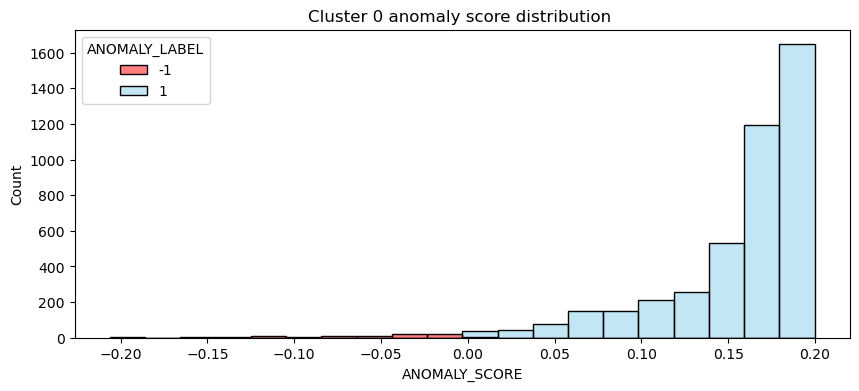

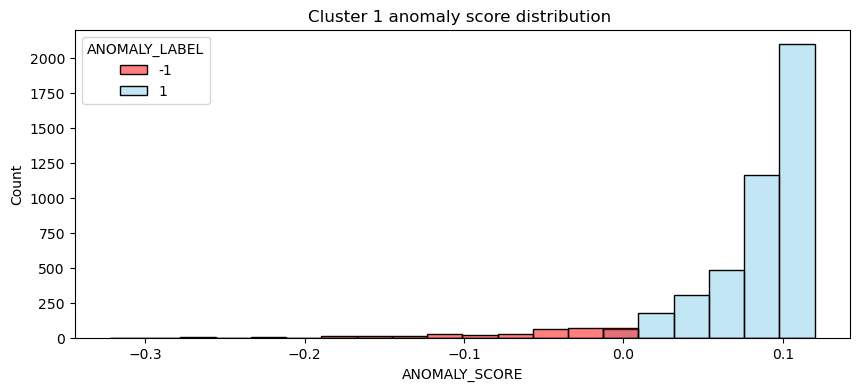

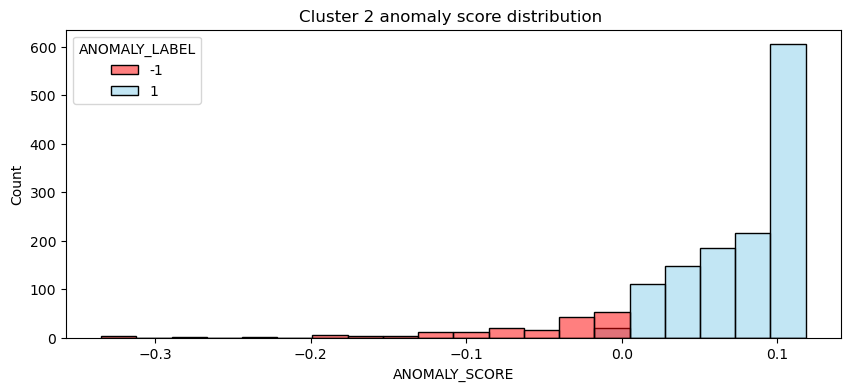

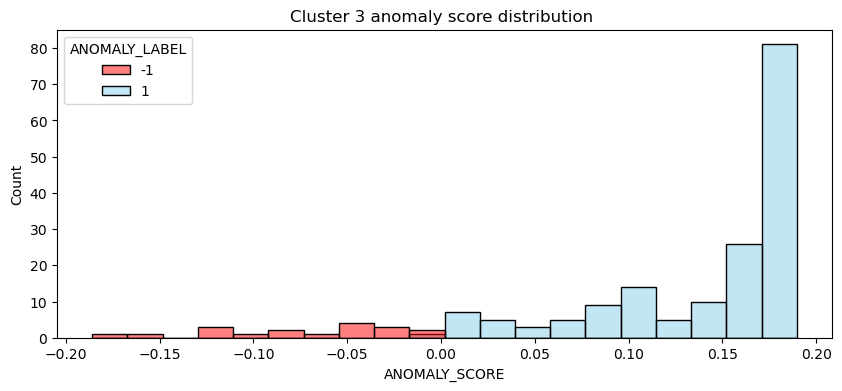

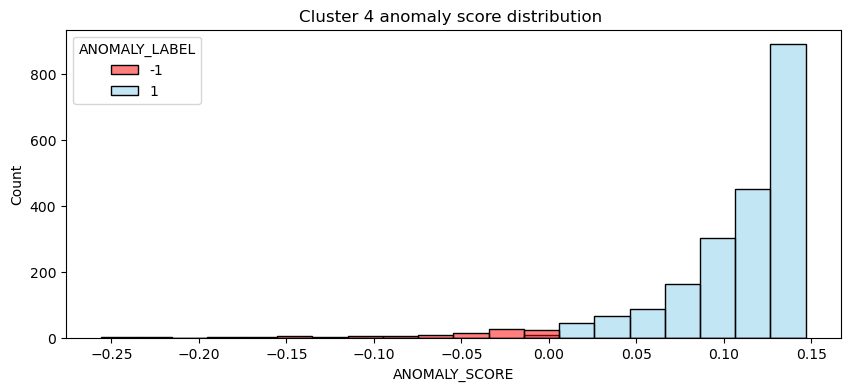

In [112]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} anomaly score distribution ')
    sns.histplot(data =cluster_df,x = 'ANOMALY_SCORE', bins=20, hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### B. 2D scatter: ECCENTRICITY vs Mean Motion

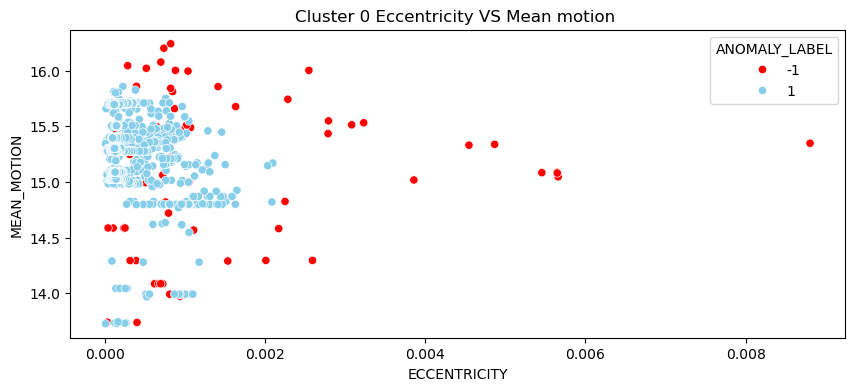

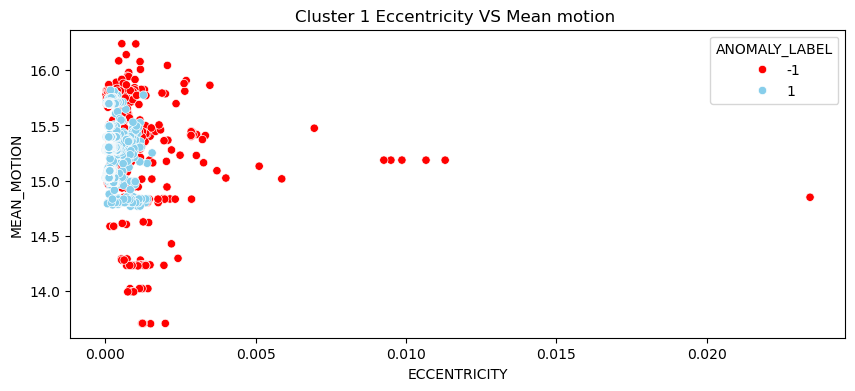

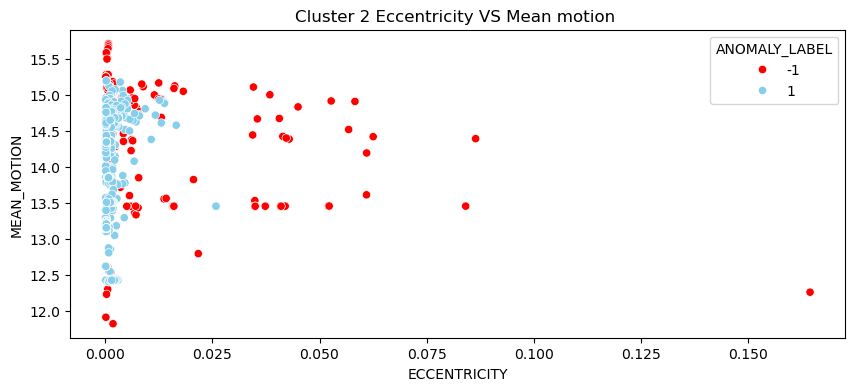

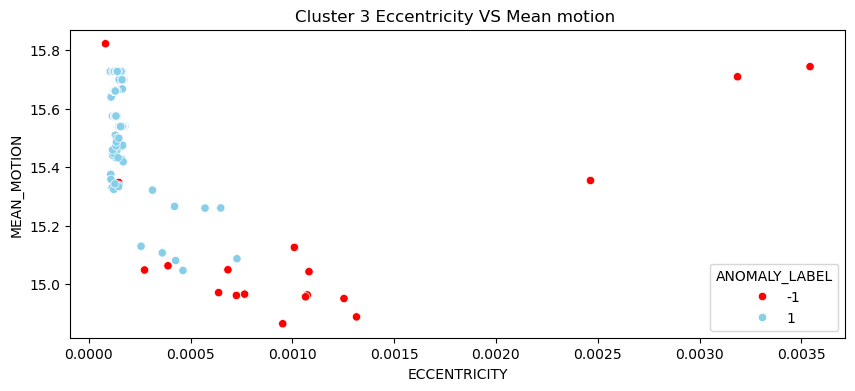

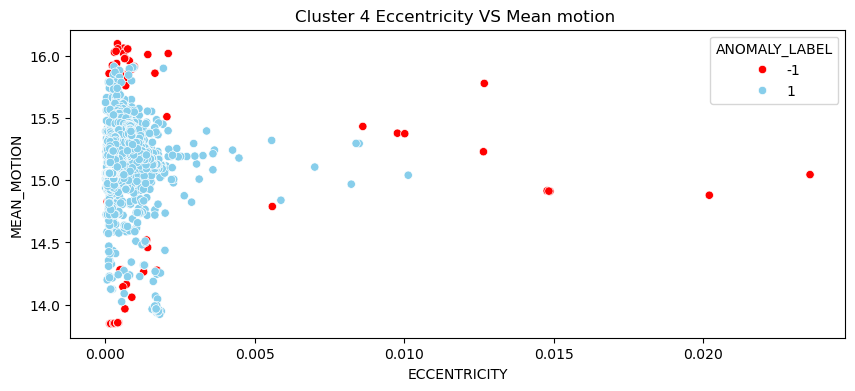

In [113]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} Eccentricity VS Mean motion ')
    sns.scatterplot(data = cluster_df,x = 'ECCENTRICITY', y = 'MEAN_MOTION', hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### C. 2D scatter: BSTAR vs MEAN MOTION

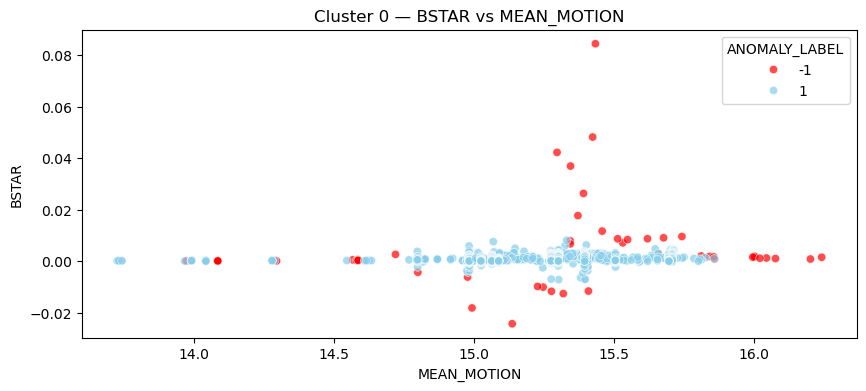

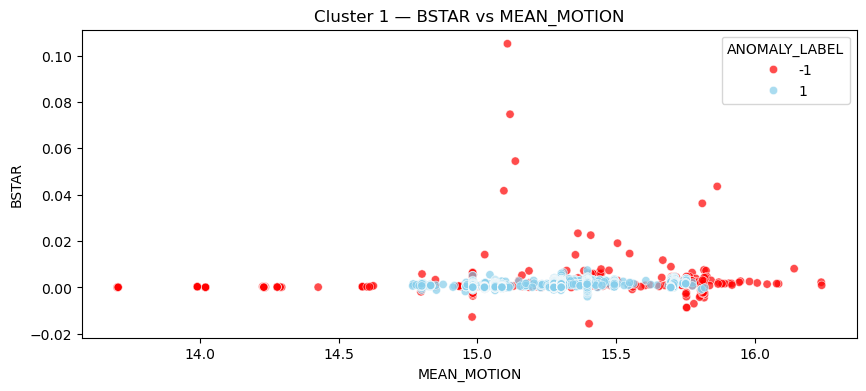

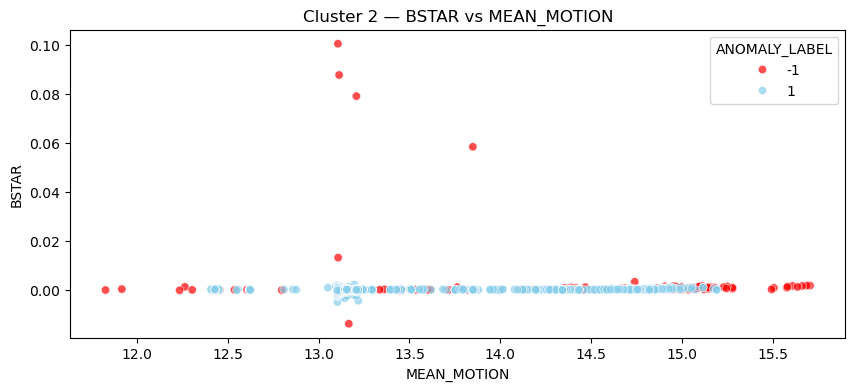

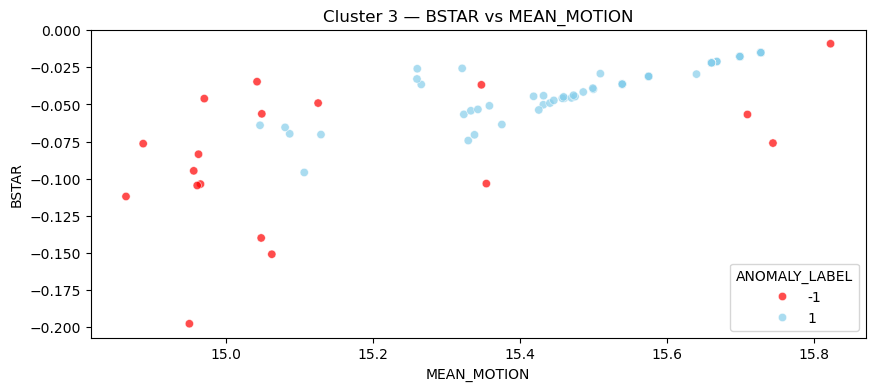

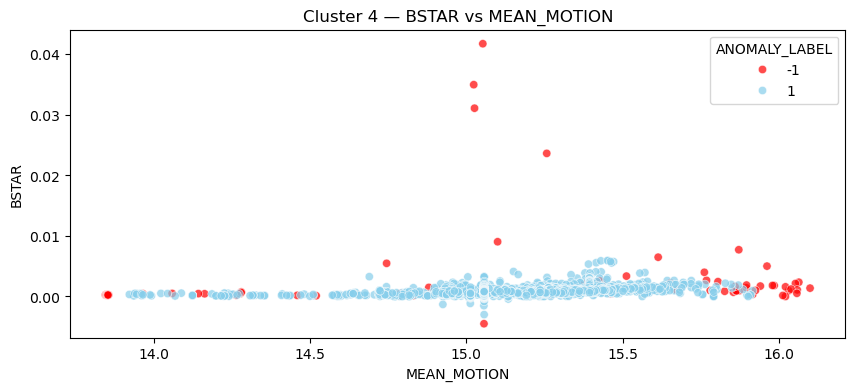

In [114]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} — BSTAR vs MEAN_MOTION')
    sns.scatterplot(
        data=cluster_df,
        x='MEAN_MOTION',
        y='BSTAR',
        hue='ANOMALY_LABEL',
        palette={1: "skyblue", -1: "red"},
        alpha=0.7
    )
  

----


### 3. Per-Anomaly Feature Deviation Detection

In [115]:
# Define  cyclical features : These are features that are cyclical in nature 
# (Eg: if RA_OF_ASC_NODE is 359, then 0 is also close, while 250 is actually far from 0!)

cyclical_features = ['RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY']

all_anomalies = []

for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # 1. Get Cluster Data
    cluster_df = anomaly_df[anomaly_df['CLUSTER'] == cluster_id]
    
    # 2. Calculate Mean AND Standard Deviation for this cluster
    features = scaled_df.columns # The features used for training
    cluster_stats = cluster_df[features].agg(['mean', 'std'])
    
    # 3. Get just the anomalies
    anomalies = cluster_df[cluster_df['ANOMALY_LABEL'] == -1].copy()
    
    for i, row in anomalies.iterrows():
        z_score_dict = {}
        
        for feature in features:
            # Get cluster stats
            mu = cluster_stats.loc['mean', feature]
            sigma = cluster_stats.loc['std', feature]
            
            # Handle zero variance (avoid divide by zero)
            if sigma == 0: 
                z_score_dict[feature] = 0
                continue

            # Calculate Delta
            if feature in cyclical_features:
                # Correct cyclical distance (min distance on a circle)
                delta = abs(row[feature] - mu)
                delta = min(delta, 360 - delta)
            else:
                # Standard linear distance
                delta = abs(row[feature] - mu)
            
            # CALCULATE Z-SCORE (Standardized Deviation)
            # "How many standard deviations is this point away from the mean?"
            z_score = delta / sigma
            z_score_dict[feature] = z_score

        # Identify feature with highest Z-Score
        max_z_feature = max(z_score_dict, key=z_score_dict.get)
        max_z_value = z_score_dict[max_z_feature]
        
        anomalies.loc[i, 'TOP_DEVIATING_FEATURE'] = max_z_feature
        anomalies.loc[i, 'DEVIATION_SIGMA'] = max_z_value # Score in "Sigmas"

    all_anomalies.append(anomalies)

final_anomalies = pd.concat(all_anomalies, ignore_index=True)

In [116]:
final_anomalies

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,AGE_SINCE_LAUNCH,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE,TOP_DEVIATING_FEATURE,DEVIATION_SIGMA
0,15.225106,0.000832,25.5810,113.7385,189.4267,0.000247,0.000062,0.0,17.925,0,-1,-0.091357,AGE_SINCE_LAUNCH,9.831728
1,15.062397,0.000724,6.0283,50.0206,105.1525,0.001814,0.000284,0.0,13.925,0,-1,-0.119623,AGE_SINCE_LAUNCH,7.259181
2,15.348146,0.008804,64.6495,22.1031,229.9544,0.001454,0.000562,0.0,13.925,0,-1,-0.168685,ECCENTRICITY,26.237952
3,14.819796,0.000758,5.9960,120.5261,128.7103,0.000283,0.000030,0.0,10.923,0,-1,-0.107518,INCLINATION,5.836511
4,15.331098,0.004546,64.7619,41.2481,124.8928,0.002017,0.000674,0.0,10.925,0,-1,-0.136690,ECCENTRICITY,13.229842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,13.851956,0.000410,81.3021,32.1119,22.7323,0.000255,0.000003,0.0,0.925,4,-1,-0.007230,INCLINATION,6.007231
695,13.852724,0.000425,81.3019,32.1063,27.0755,0.000226,0.000003,0.0,0.925,4,-1,-0.013019,INCLINATION,6.007307
696,13.848390,0.000254,81.3046,32.1418,357.3373,0.000247,0.000003,0.0,0.925,4,-1,-0.068830,INCLINATION,6.006285
697,13.849206,0.000285,81.3037,32.1329,0.6252,0.000255,0.000003,0.0,0.925,4,-1,-0.036121,INCLINATION,6.006626


In [117]:
final_anomalies['CLUSTER'].value_counts()

CLUSTER
1    323
2    175
4     95
0     88
3     18
Name: count, dtype: int64

In [118]:
anomaly_df['ANOMALY_LABEL'].value_counts()

ANOMALY_LABEL
 1    12048
-1      699
Name: count, dtype: int64

In [119]:
final_anomalies['TOP_DEVIATING_FEATURE'].value_counts()

TOP_DEVIATING_FEATURE
MEAN_MOTION          174
INCLINATION          136
AGE_SINCE_LAUNCH     130
ECCENTRICITY         114
MEAN_MOTION_DOT       61
BSTAR                 51
ARG_OF_PERICENTER     17
MEAN_MOTION_DDOT      14
RA_OF_ASC_NODE         2
Name: count, dtype: int64